In [92]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from parameters import *
from data import * 

In [94]:
with open("../data/user_interaction_log.json", "r") as f:
    data = json.load(f)
    profile = data["user_profile"]
    interactions = data["interactions"]
with open("../data/dummy_feed.json", "r") as f:
    properties = json.load(f)

In [95]:
from generators.score import *

now = datetime.now()
prop_map = {p["id"]: p for p in properties}

interaction_count = len(interactions)
alpha, beta = compute_alpha_beta(interaction_count)
user_vec = build_user_vector(interactions, properties)
session_ctx = build_session_context(interactions)

implicit_map = {p["id"]: 0.0 for p in properties}
session_map = {p["id"]: 0.0 for p in properties}

In [96]:
for event in interactions:
    pid = event["listing_id"]
    if pid not in prop_map: continue
    dt = (now - datetime.fromisoformat(event["timestamp"])).total_seconds() / 3600
    d_i = compute_di(event["dwell_time_sec"], event["activity_factor"])

    implicit_map[pid] += event["weight"] * d_i * np.exp(-LAMBDA_HISTORICAL * dt)
    match_score = compute_match_score(event, session_ctx) 
    session_map[pid] += event["weight"] * match_score * d_i * np.exp(-LAMBDA_SESSION * dt)

results = []
epsilon = EPSILON_NEW_USER if interaction_count < 20 else EPSILON_OLD_USER

for p in properties:
    pid = p["id"]
    p_vec = build_property_vector(p)
    post_age = (now - datetime.fromisoformat(p["created_at"])).total_seconds() / 3600

    explicit = np.dot(user_vec, p_vec) * compute_distance_score(profile["target_lat"], profile["target_lng"], p["lat"], p["lng"])

    implicit = np.tanh(implicit_map[pid])
    session = np.tanh(session_map[pid])

    rel_final = compute_relevance_final(explicit, implicit, session, alpha, beta)
    freshness = compute_freshness(post_age)
    B = compute_B(p["authority"])

    score_raw = compute_raw_rank_score(rel_final, freshness, B, post_age)
    score_bubble = apply_anti_bubble(score_raw, epsilon)

    results.append({
        "id": pid,
        "property_type": p["property_type"],
        "score_before_log": score_bubble,
        "explicit": explicit,
        "implicit": implicit_map[pid],
        "session": session_map[pid],
        "freshness": freshness,
        "B": B
    })

results.sort(key=lambda x: x["score_before_log"], reverse=True)
results = apply_diversity_penalty(results)
results = percentile_normalize(results)

results = pd.DataFrame(results)
results.head(10)

,id,property_type,score_before_log,explicit,implicit,session,freshness,B,final_score_log,norm_score
0,bd369dc7,material,4.593039,1.355677e-06,9.969453,1.118257e-02,0.379752,2.590682,1.721523,1.000000
1,026336a8,house,4.475027,2.748299e-07,0.801930,4.452014e-03,0.182095,2.499277,1.700197,0.998999
2,d1776848,construction,4.443648,2.897418e-01,0.356980,2.748731e-21,0.363659,2.433208,1.694449,0.997998
3,22bf9973,apartment,4.132297,5.987431e-02,10.868538,2.139677e-05,0.177300,2.149674,1.635553,0.996997
4,45f7e7d0,condo,3.944019,4.194042e-06,0.711992,2.730490e-13,0.117108,1.970353,1.598179,0.995996
5,ba63699c,land,3.892328,1.039742e-10,1.039986,2.258777e-06,0.615041,1.876327,1.587668,0.994995
6,cd193a80,house,2.078808,2.098597e-07,4.080823,9.520715e-12,0.219147,2.174282,1.124543,0.993994
7,368c9297,material,2.052171,1.685430e-05,10.274052,2.989674e-06,0.211095,2.118474,1.115853,0.992993
8,e2d8c645,construction,1.997666,7.906061e-07,8.049238,4.050155e-05,0.892131,1.936475,1.097834,0.991992
9,d03e049e,apartment,1.920464,1.753197e-07,6.365621,6.191059e-05,0.303543,1.844383,1.071742,0.990991


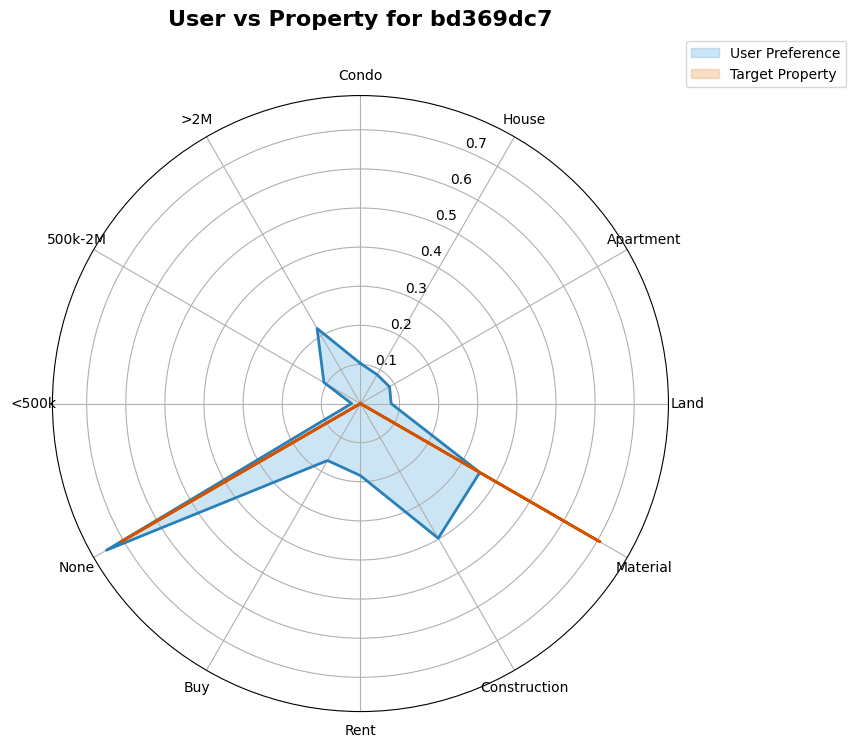

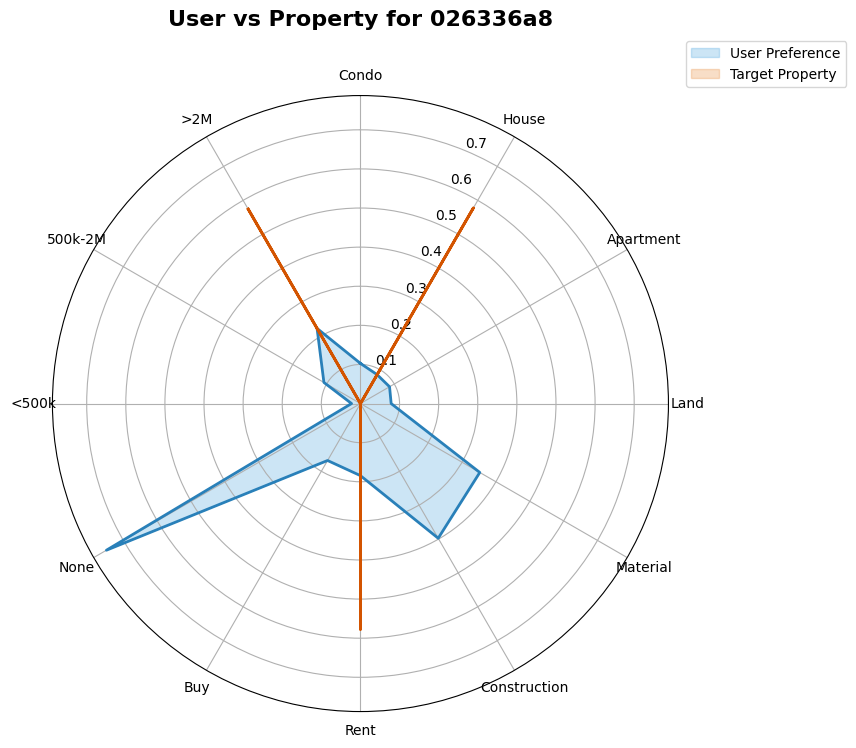

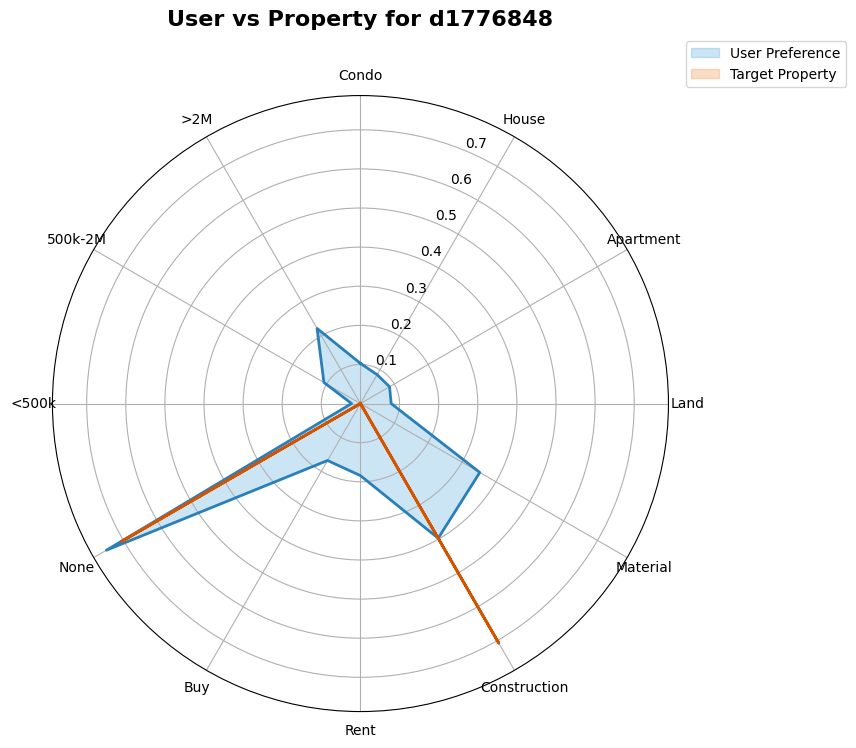

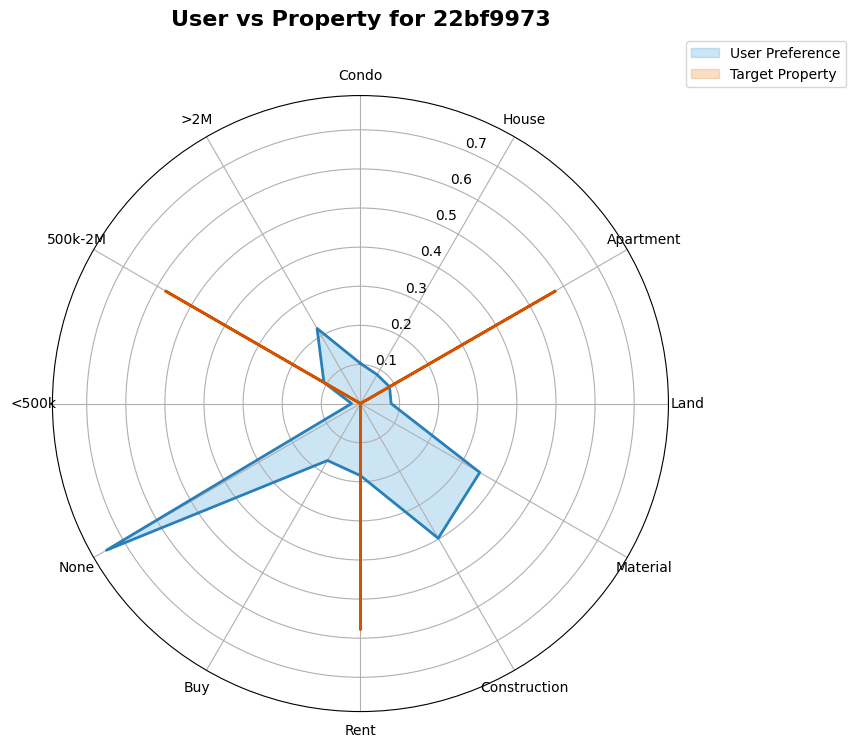

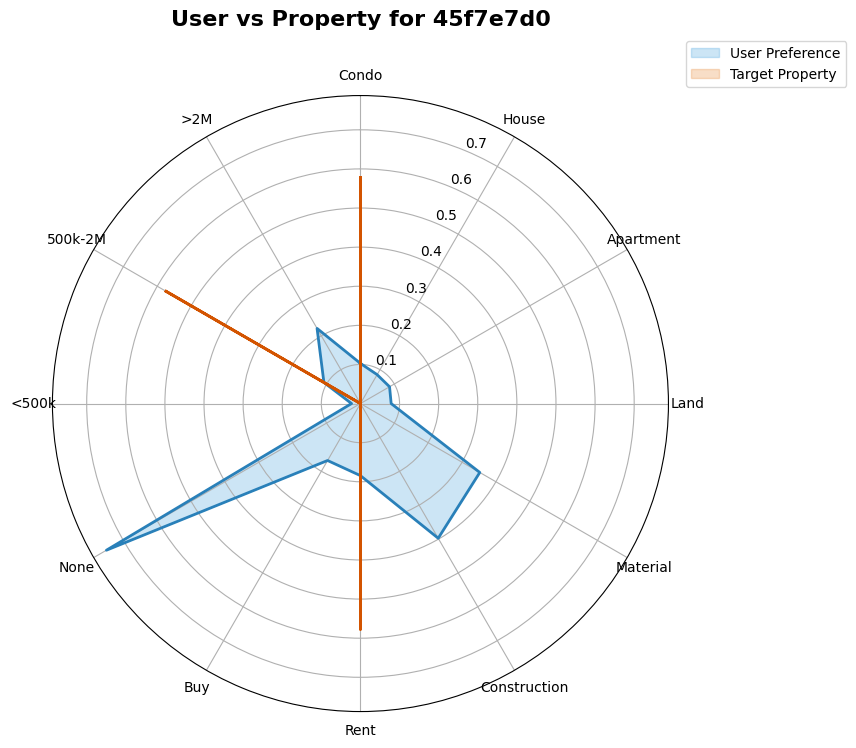

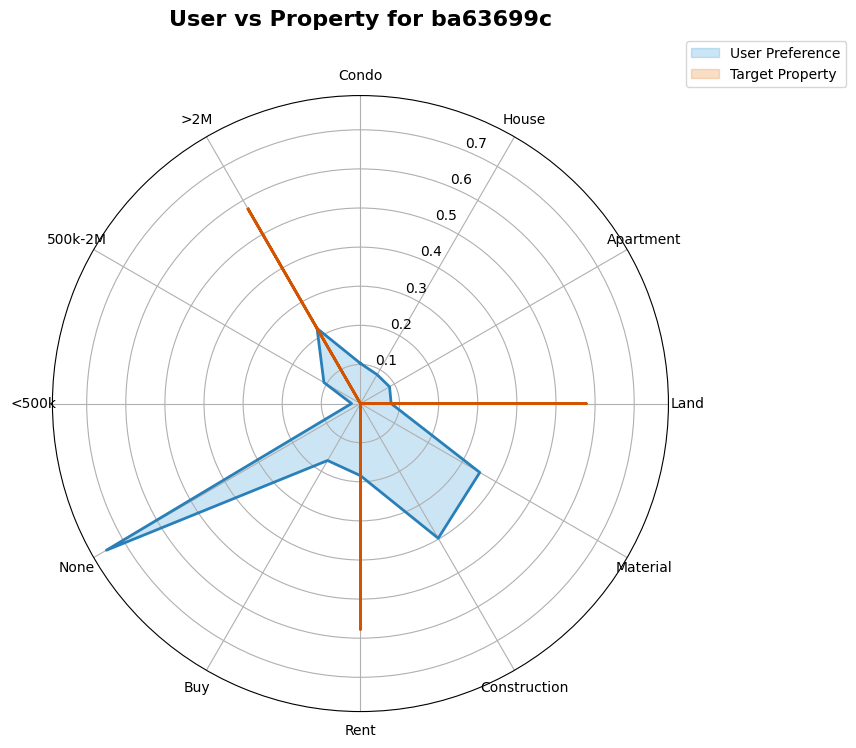

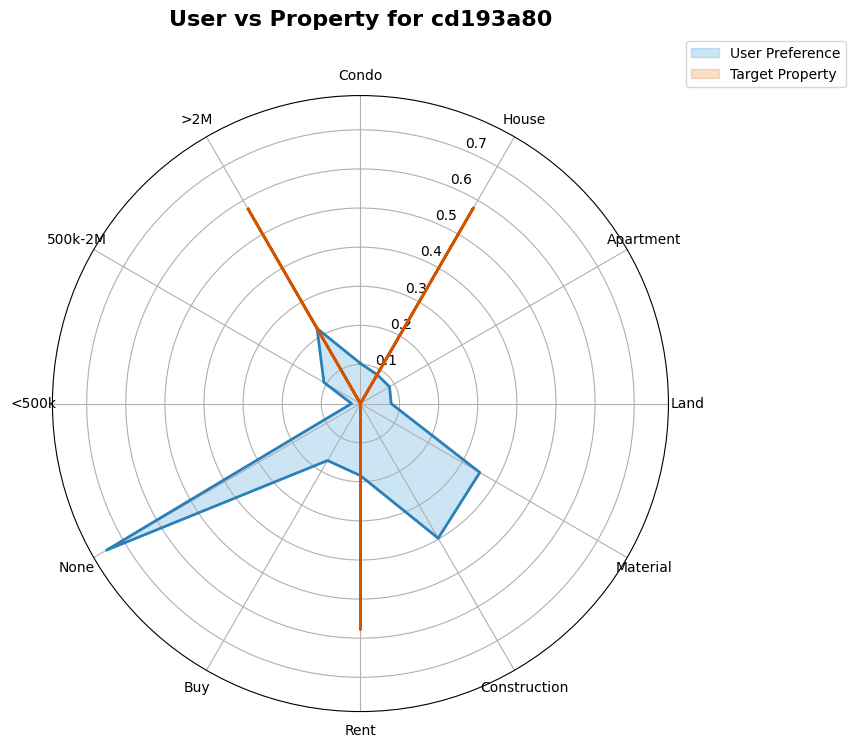

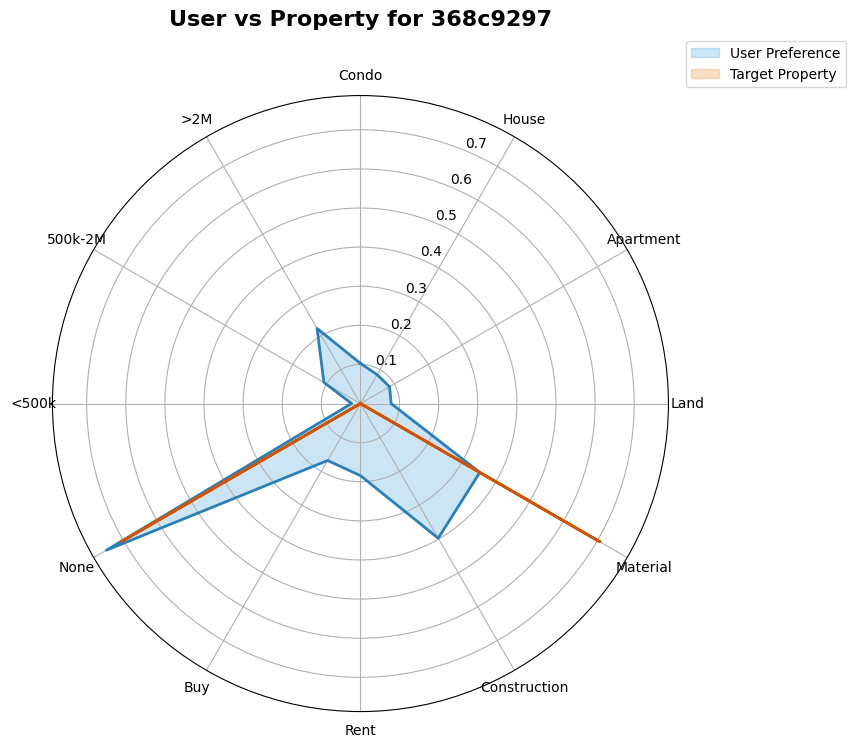

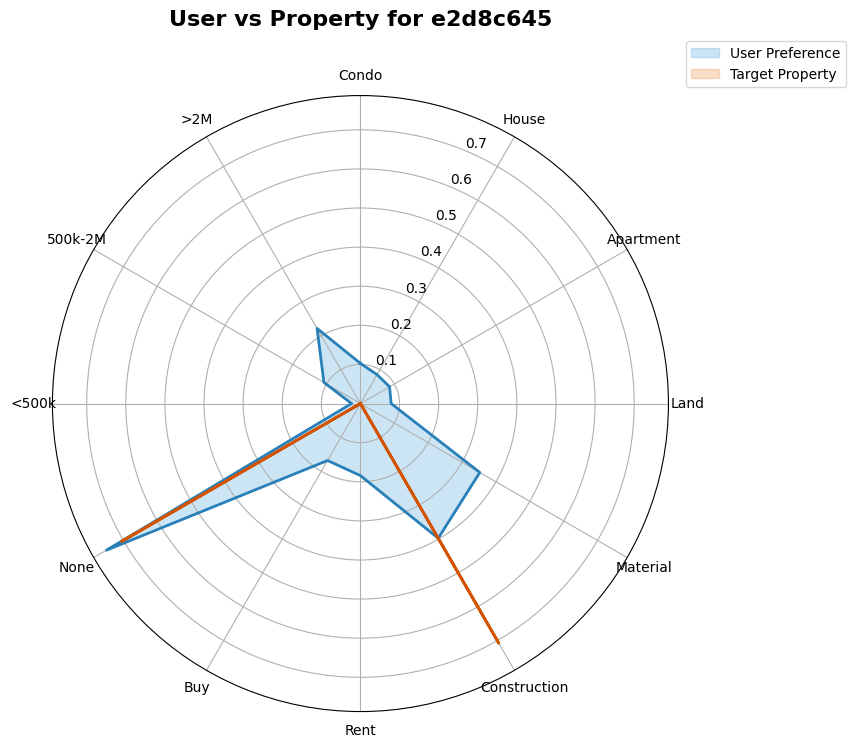

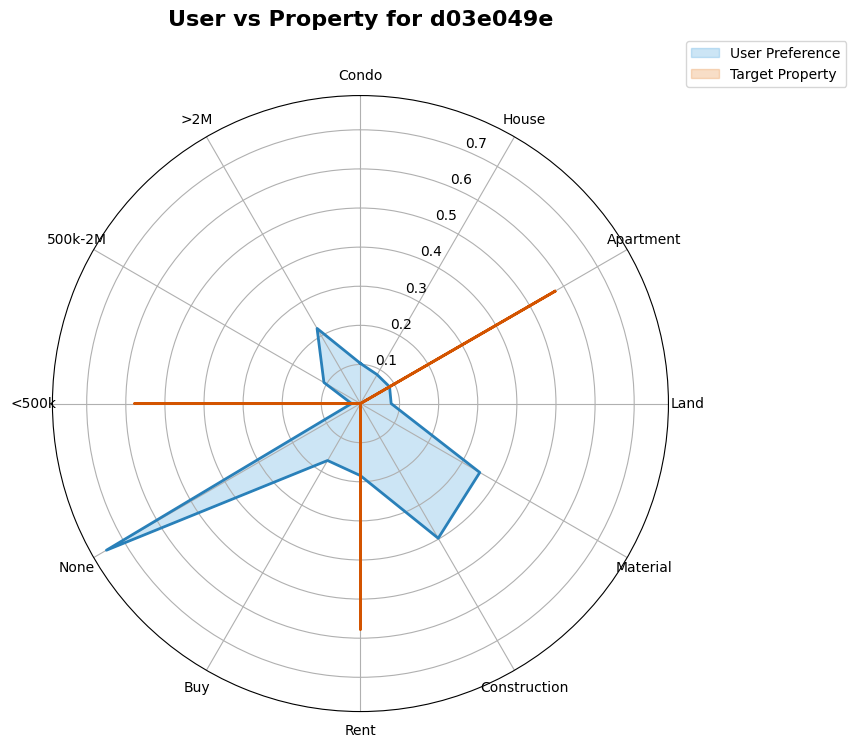

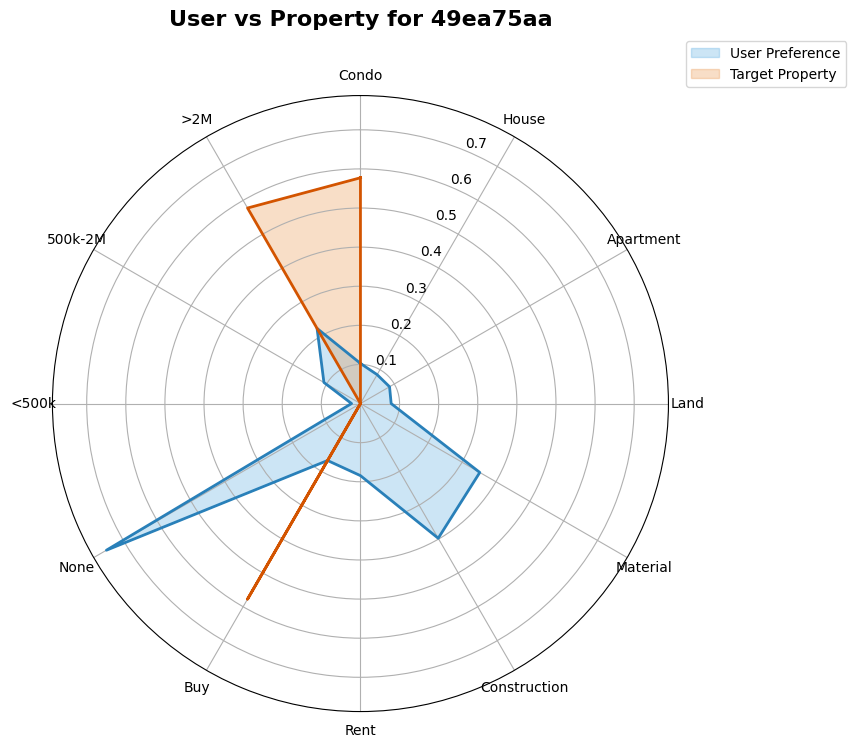

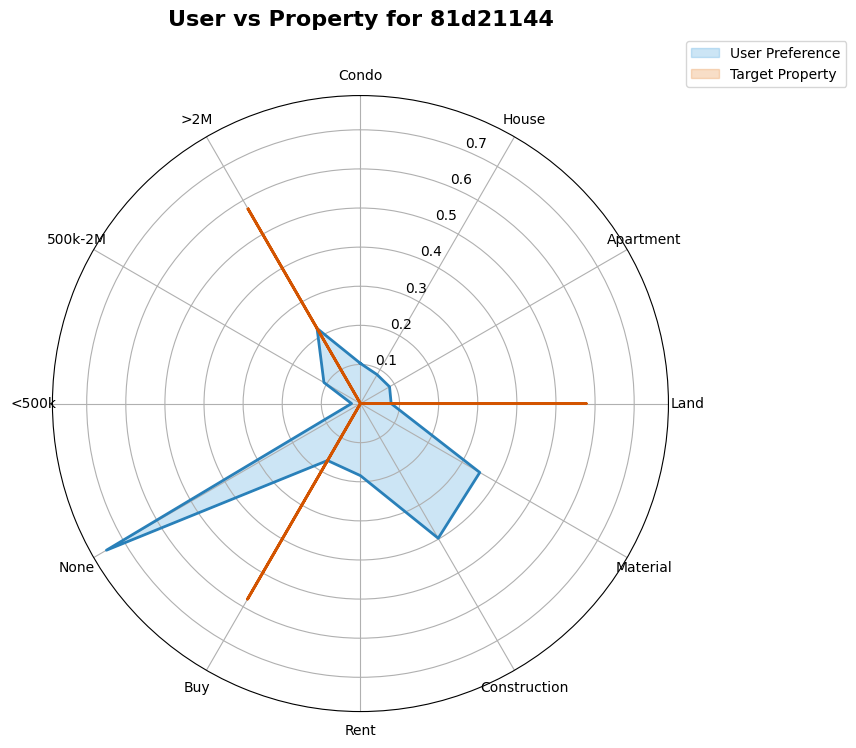

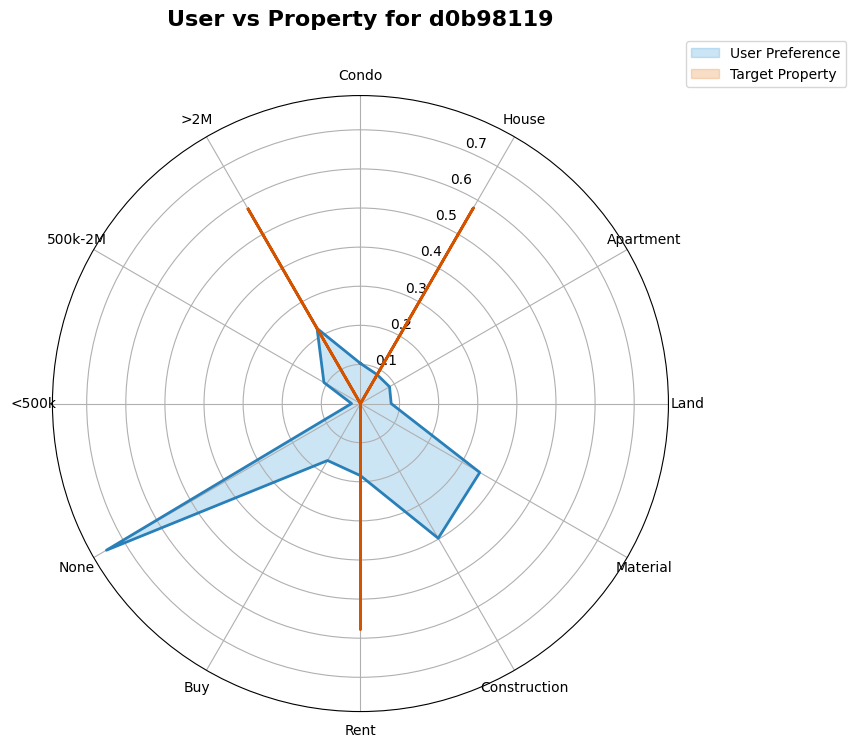

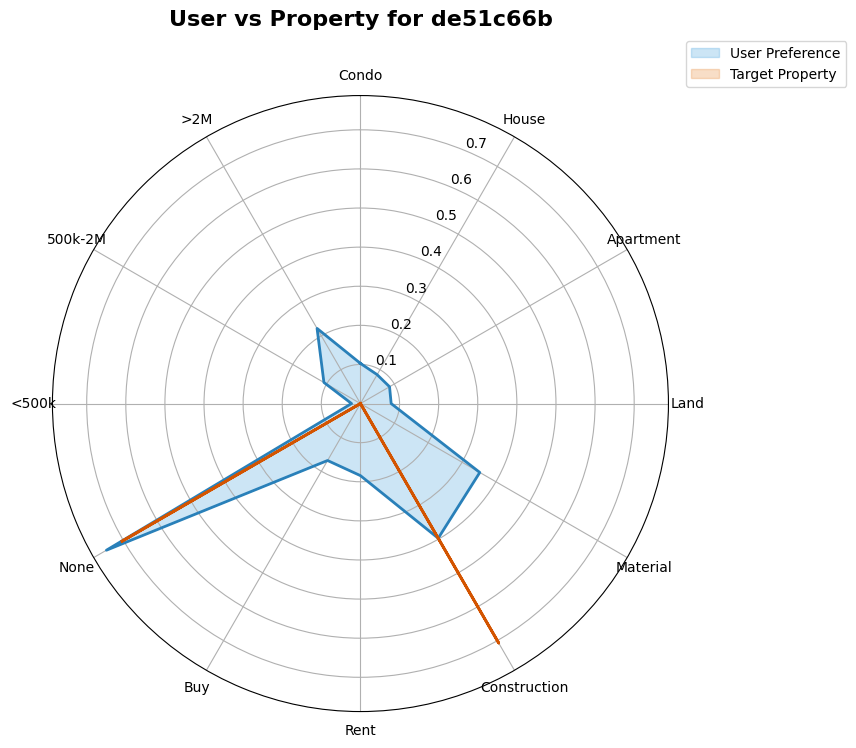

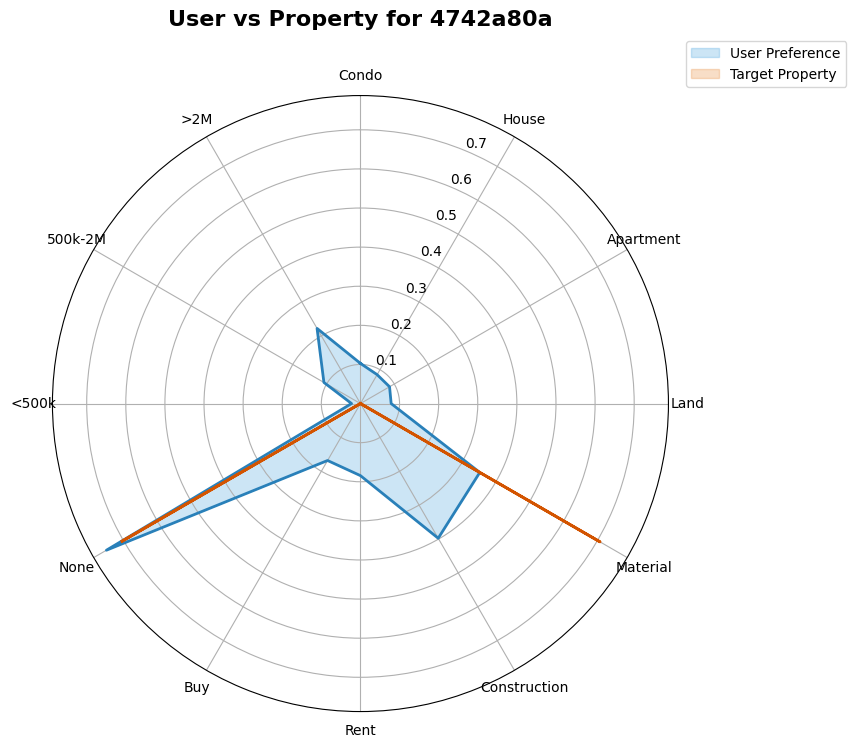

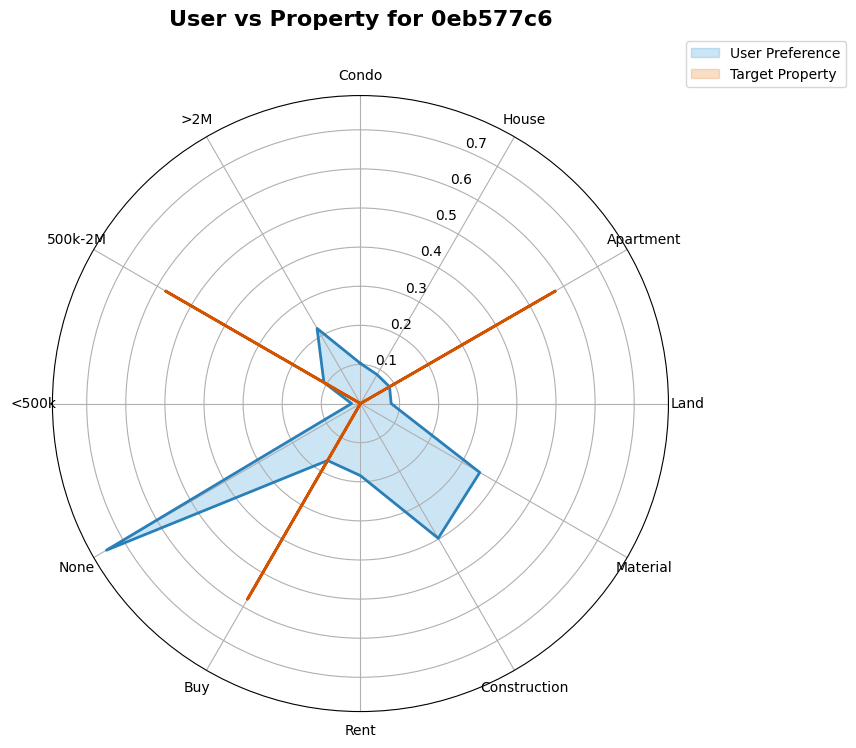

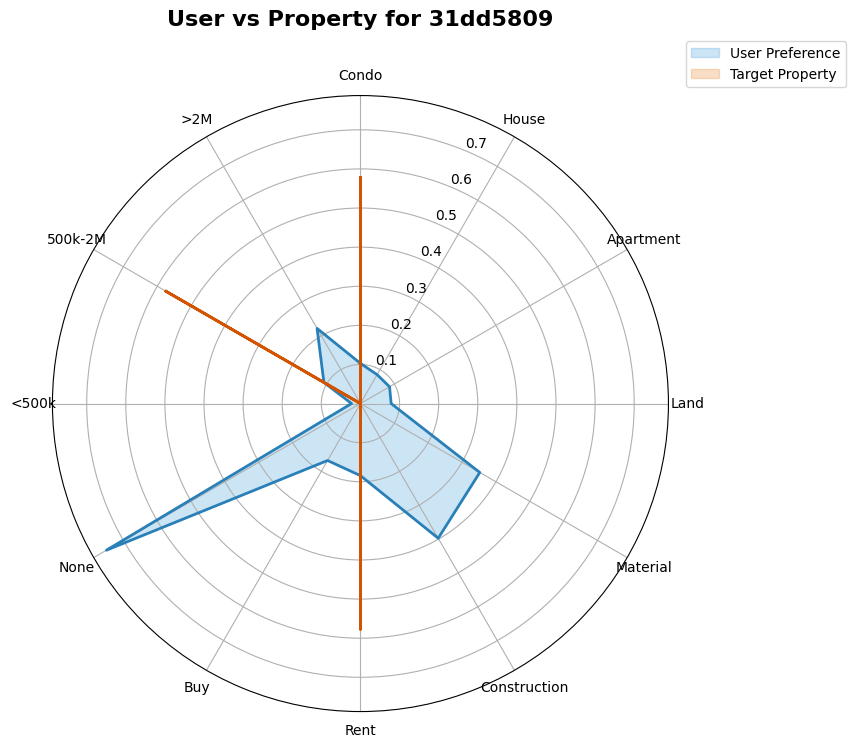

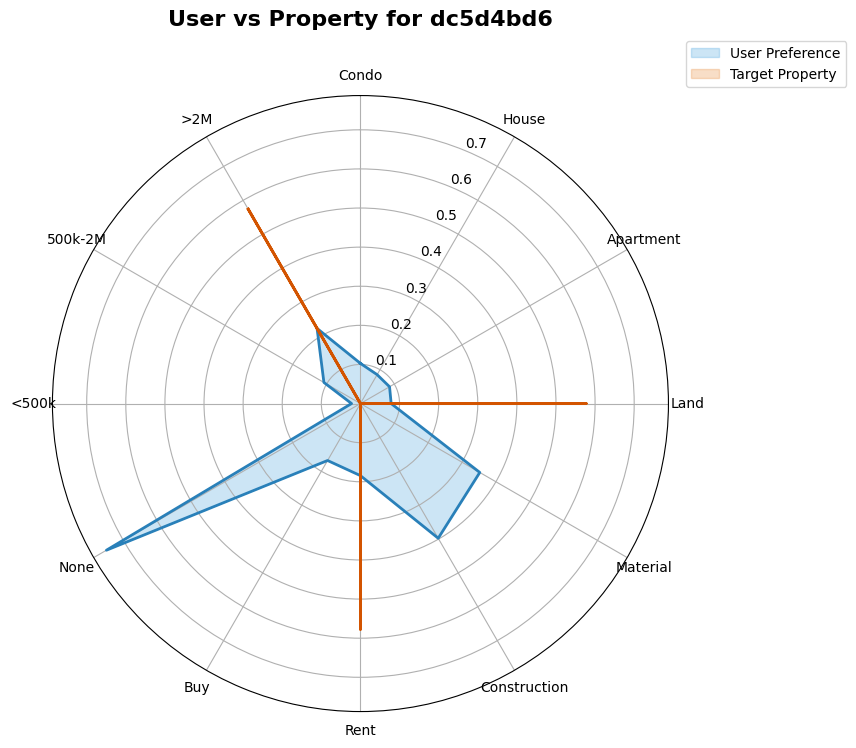

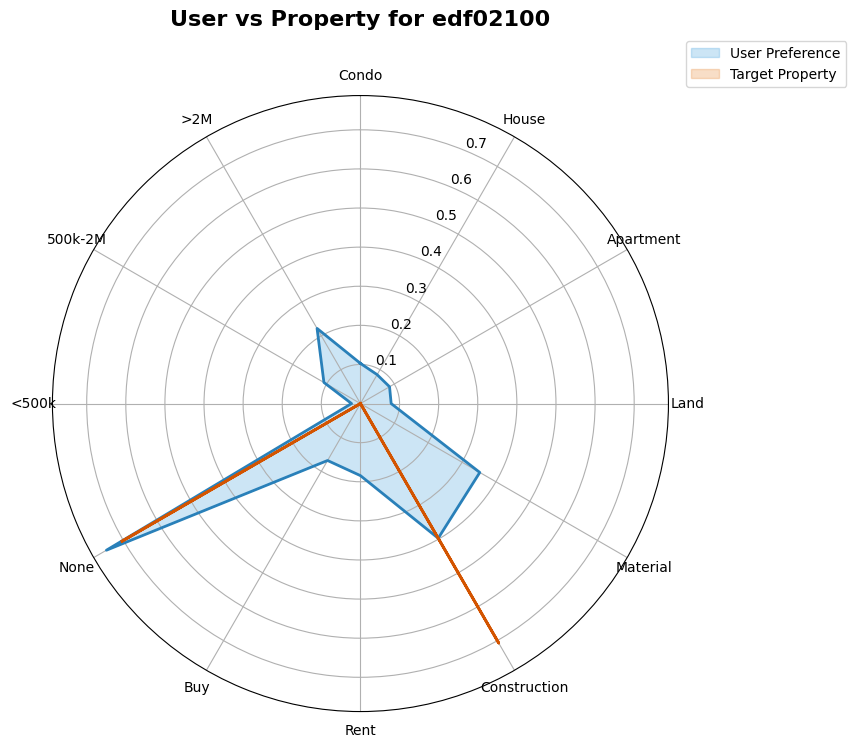

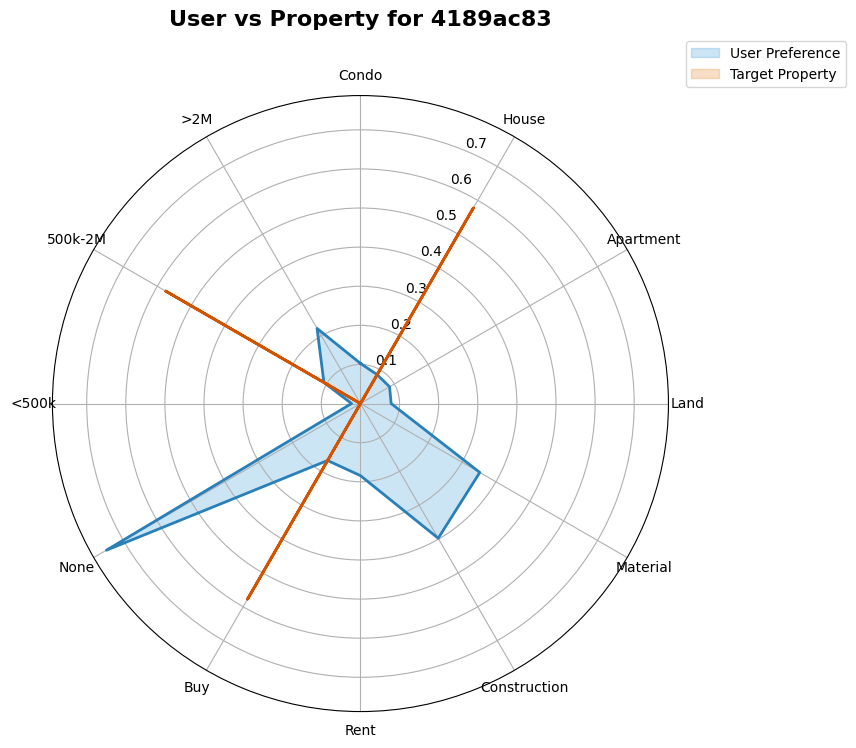

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your labels (must match your 12D vector order)
labels = [
    'Condo', 'House', 'Apartment', 'Land', 'Material', 'Construction', 
    'Rent', 'Buy', 'None', '<500k', '500k-2M', '>2M'
]

def plot_sunfire_radar(user_vec, prop_vec, title):
    num_vars = len(labels)
    
    # Calculate angles for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    
    # "Close" the loop for the radar chart
    angles += angles[:1]
    user_vec = np.append(user_vec, user_vec[0])
    prop_vec = np.append(prop_vec, prop_vec[0])

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Plot User Vector (The Blueprint)
    ax.fill(angles, user_vec, color='#3498db', alpha=0.25, label='User Preference')
    ax.plot(angles, user_vec, color='#2980b9', linewidth=2)

    # Plot Property Vector (The Reality)
    ax.fill(angles, prop_vec, color='#e67e22', alpha=0.25, label='Target Property')
    ax.plot(angles, prop_vec, color='#d35400', linewidth=2)

    # Aesthetics
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # Fix labels to axes
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    
    # Add legend and title
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title(title, size=16, y=1.1, fontweight='bold')
    
user_v = build_user_vector(interactions, properties)
for i in results.head(20).values:
    for p in properties:
        if p["id"] == i[0]:
            prop_v = build_property_vector(p)
            plot_sunfire_radar(user_v, prop_v, f"User vs Property for {i[0]}")